K-means

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

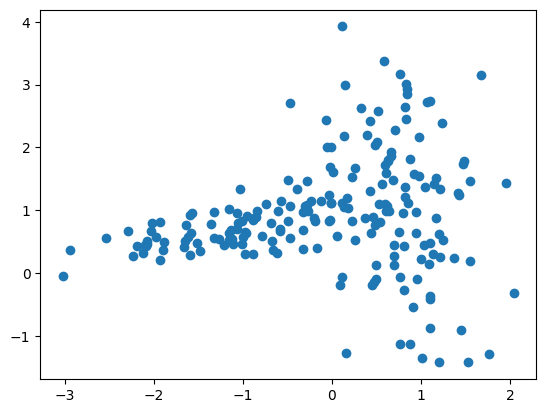

In [ ]:
from sklearn.datasets import make_classification
Xc_2,_= make_classification(n_samples=200, n_features=2, n_informative=2, n_redundant=0, random_state=0, n_clusters_per_class=1, class_sep = 0.8)

def initialize_centroids(X, K):
    random_indices = np.random.choise(X.shape[0], K, replace = False)
    return X[random_indices]

def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

def compute_centroids(X, labels, K):
    centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        cluster_points = X[labels == k]
        if len(cluster_points) > 0:
            centroids[k] = np.mean(cluster_points, axis=0)
        else:
            centroids[k] = X[np.random.choice(X.shape[0])]
    return centroids

def compute_cost(X, labels, centroids):
    m = X.shape[0]
    cost = 0
    for i in range(m):
        assigned_centroid = centroids[labels[i]]
        cost += np.sum((X[i] - assigned_centroid) ** 2) 
    return cost / m

def run_kmeans_once(X, K, max_iters=100):
    centroids = initialize_centroids(X, K)
    prev_cost = float('inf')
    
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        centroids = compute_centroids(X, labels, K)
        cost = compute_cost(X, labels, centroids)
        if prev_cost - cost < 1e-6:
            break
        prev_cost = cost
        
    return labels, centroids, cost

def run_kmeans_once(X, K, max_iters=100):
    centroids = initialize_centroids(X, K)
    prev_cost = float('inf')
    
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        centroids = compute_centroids(X, labels, K)
        cost = compute_cost(X, labels, centroids)
        if prev_cost - cost < 1e-6:
            break
        prev_cost = cost
    return labels, centroids, cost

def kmeans(X, K, n_init=100):
    best_cost = float('inf')
    best_labels = None
    best_centroids = None
    
    for _ in range(n_init):
        labels, centroids, cost = run_kmeans_once(X, K)
        if cost < best_cost:
            best_cost = cost
            best_labels = labels
            best_centroids = centroids
    return best_labels, best_centroids, best_cost

plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])